<a href="https://colab.research.google.com/github/AninditaSanjagiri/NASA-Exoplanet-detection/blob/main/Lightkurve.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Finding Exoplanets Using NASA's Telescope Data 🔭🪐**

## 🌌 Introduction

Have you ever wondered how astronomers discover planets that are **trillions of kilometres away**?

You can actually try it yourself.

In this notebook, we will use **Python** and publicly available data from NASA's space telescopes to search for the subtle signatures of planets orbiting distant stars. We will use the **transit method**, where an exoplanet is detected by observing a tiny, periodic decrease in its star's brightness as the planet passes in front of it.

The data we will work with comes from NASA's **Missions Archive at the Space Telescope Science Institute (MAST)**, which contains observations collected by missions such as **Kepler** and **TESS**. To work with this data, we will use **Lightkurve**, a Python library designed for analysing astronomical time-series data.

You do **not** need access to a telescope or specialised astronomical equipment for this project. Everything we need can be done from a browser using **Google Colab**.

### 🔭 What we'll do

Throughout this notebook, we will:

1. Retrieve real telescope observations of a target star.
2. Visualise the star's brightness over time.
3. Clean and flatten the light curve to remove unwanted variations.
4. Search for repeating dips in brightness.
5. Use a **periodogram** to identify possible orbital periods.
6. Fold the light curve around the suspected period.
7. Examine the resulting transit signal.
8. Apply the same approach to other stars and explore potential exoplanet candidates.

The goal is not simply to run a piece of code and get a result. **You will learn how to go from raw telescope observations to a potential exoplanet signal.**

> **Important:** A repeating dip in brightness is not automatically proof that an exoplanet exists. Astronomers perform additional checks to distinguish genuine planetary transits from stellar activity, instrumental effects, eclipsing binaries, and other false positives.

By the end of this notebook, you should have a basic understanding of how real astronomical data can be analysed with Python to search for worlds beyond our Solar System.

**Let's find an exoplanet.** 🪐



`

-Anindita Sanjagiri (Author)


`







In [1]:
#Installs the Lightkurve Python library, which we’ll use to access and analyse space telescope data.

pip install lightkurve

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 75.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.4/15.4 MB 77.9 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=945b41e6f62879ca464f4055b2fc48904017139dfabbd2df7e5aaa6aa6ded214
  Stored in directory: /root/.cache/pip/wheels/30/85/d4/289ba063a9ae0ba3189c6914e992722575868b2cb41100401b
  Created wheel for memoization

In [4]:
#Imports search_targetpixelfile from Lightkurve to search for telescope data of a specific star.

from lightkurve import search_targetpixelfile
pixelfile=search_targetpixelfile("KIC 8462852", quarter=16).download(quality_bitmask='hardest');       #Searches for the target star's pixel data from Quarter 16 and downloads the highest-quality data available.




> Here, The targetpixelfile refers to the camera pixels produced by Kepler or TESS telescope. For Kepler, all the files are 5X5, a square representing a star or a galaxy. These files are a collection of time frames of the same location.




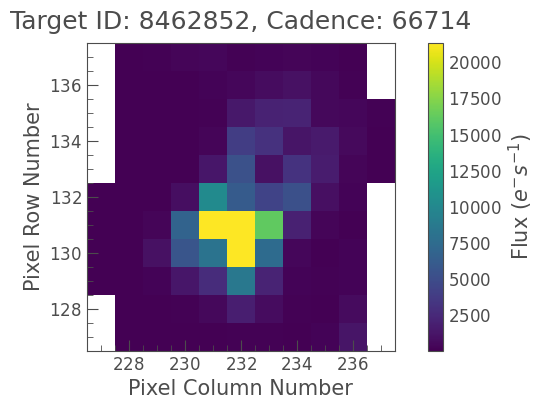

In [5]:
# Lets observe it by using the following code

pixelfile.plot(frame=1);

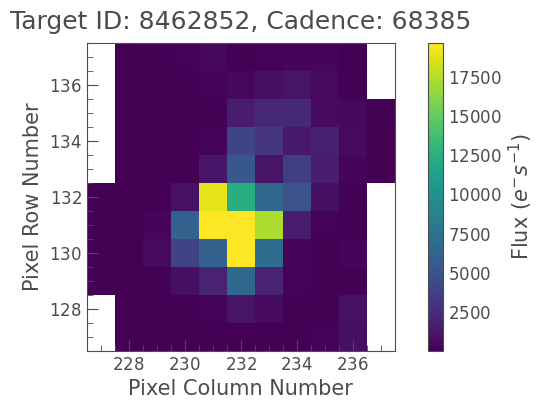

In [8]:
pixelfile.plot(frame=1000);

In [11]:
#Converts the pixel data into a light curve, which records how the star's brightness changes over time. aperture_mask='all' uses all available pixels around the target star.

lc=pixelfile.to_lightcurve(aperture_mask='all');


In [12]:
#Displays the two main parts of the light curve: lc.time contains the observation times, while lc.flux contains the star's brightness measurements at those times.

lc.time, lc.flux



(<Time object: scale='tdb' format='bkjd' value=[1472.11777934 1472.13821223 1472.15864492 ... 1557.89718798 1557.9380561
  1557.95849016]>,
 <Quantity [258645.03, 258660.05, 258690.08, ..., 258929.86, 258884.66,
            258865.6 ] electron / s>)

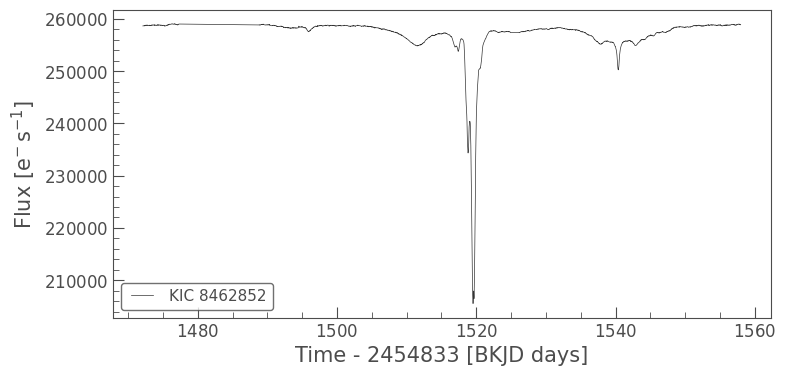

In [13]:
#Plots the light curve to visualize the star's brightness changes over time.

lc.plot();

.



> This is the light curve of the star KIC 8462852. Here's how to read it:

**X-axis**: Time → When the telescope observed the star, measured in BKJD days.

**Y-axis**: Flux → The amount of light/brightness detected from the star, measured in electrons per second.

The relatively flat region around 258,000–260,000 flux represents the star's normal brightness.

The sharp dips mean the amount of light reaching the telescope suddenly decreased.
The huge dip around 1520 days is especially noticeable. This means something temporarily blocked a significant amount of the star's light.
Smaller dips appear at other times as well.

For exoplanet detection, we're particularly interested in dips that repeat at regular intervals. A planet passing in front of its star blocks a tiny fraction of the light, producing a characteristic dip in the light curve.



> Important: This plot alone doesn't prove that an exoplanet is present. We need to process the light curve and look for periodic, consistent transit signals.





In [14]:
# Now let's look at an example that shows an actual planet

pixelFile=search_targetpixelfile('KIC 6922244', quarter=4).download()

/usr/local/lib/python3.13/dist-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 4 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [15]:
#Converts the pixel data into a light curve, using the same pixel selection that NASA's Kepler pipeline used to measure the star's brightness.
#This gives us the star's brightness over time, which we can analyze for a transit signal.

lc = pixelFile.to_lightcurve(aperture_mask=pixelFile.pipeline_mask)

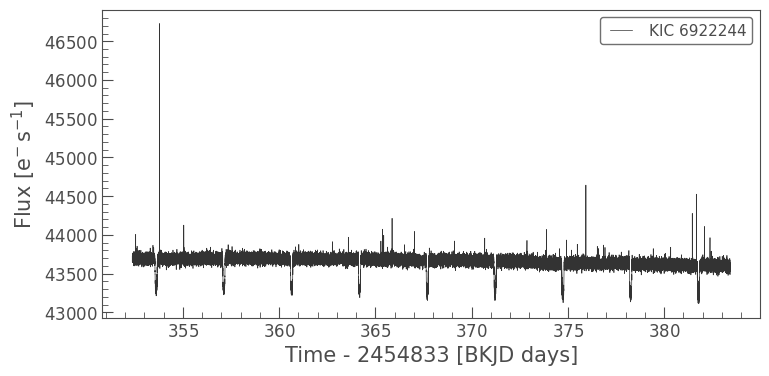

In [17]:
lc.plot();

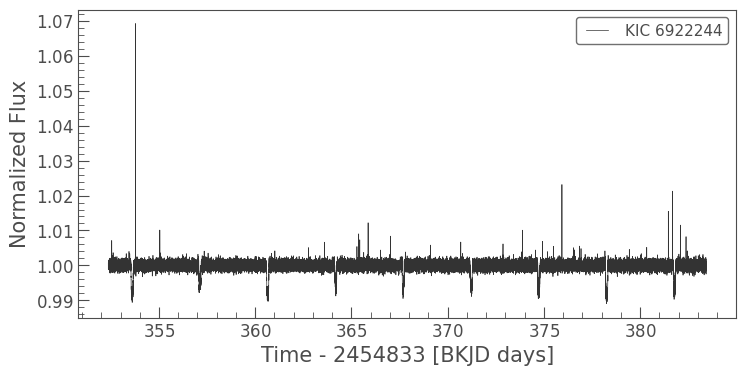

In [18]:
flat_lc=lc.flatten(window_length=401)
flat_lc.plot();

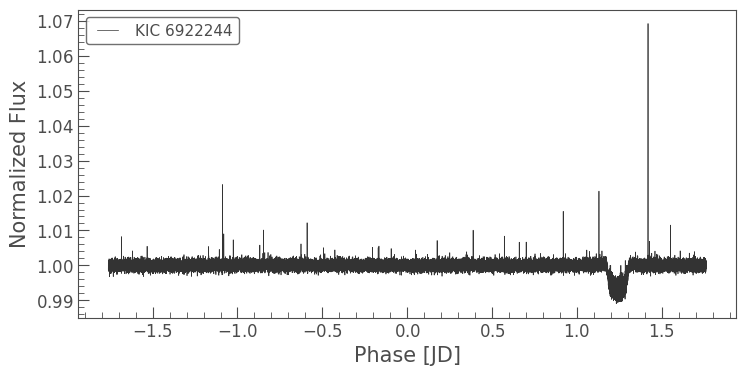

In [24]:
folded_lc=flat_lc.fold(period=3.522)
folded_lc.plot();


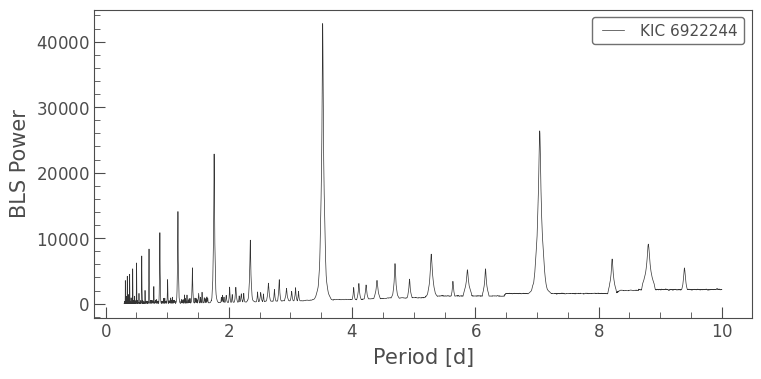

In [22]:
import numpy as np
periodogram=flat_lc.to_periodogram(method='bls',period=np.arange(0.3, 10, 0.001),duration=np.arange(0.05, 0.3, 0.01))
periodogram.plot();

***The BLS periodogram tests a range of possible orbital periods and calculates the strength of the transit signal at each period. The strongest peak occurs near 3.52 days, suggesting that this is the orbital period of the planet.🔭🪐***

In [23]:
best_fit_period=periodogram.period_at_max_power
print('Best Fit Period: {: .3f}'.format(best_fit_period))

Best Fit Period:  3.522 d


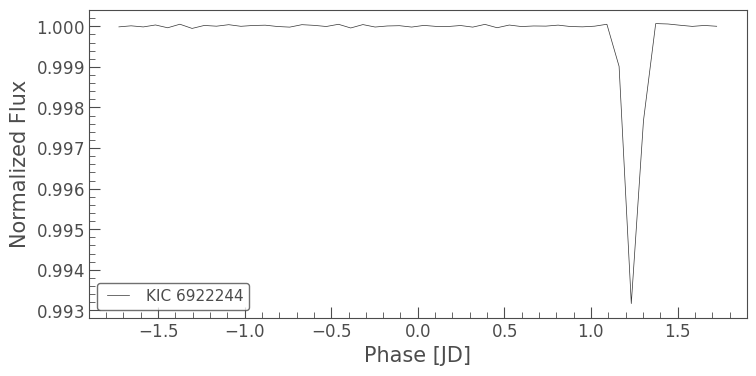

In [31]:
# To make the graph even more readable, instead of considering every point, lets make bins (groups) of 10 points

binned_lc = folded_lc.bin(bins=50)

binned_lc.plot();

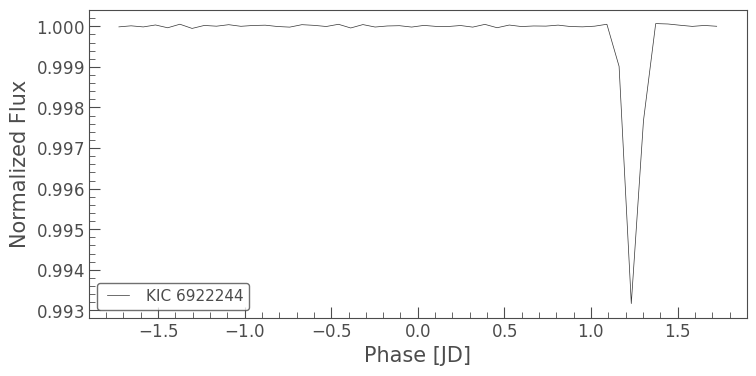

In [33]:
# To cover all the modification done
# This can be used

lc.remove_nans().flatten(window_length=401).fold(period=3.522).bin(bins=50).plot();

.


## **So far we have covered the basics to see how planets are found✨**
**Using already discovered planets.**
**Let's proceed to the TESS data now**


In [34]:
# Let's have a look at the Planet- "Pi Mensae"

import lightkurve as lk
search_result=lk.search_targetpixelfile('Pi Mensae', mission='TESS', sector=1)
tpf=search_result.download(quality_bitmask='hardest')

/usr/local/lib/python3.13/dist-packages/lightkurve/search.py:421: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


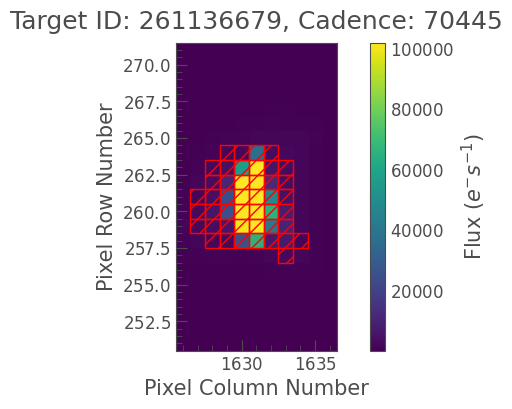

In [35]:
tpf.plot(aperture_mask=tpf.pipeline_mask);

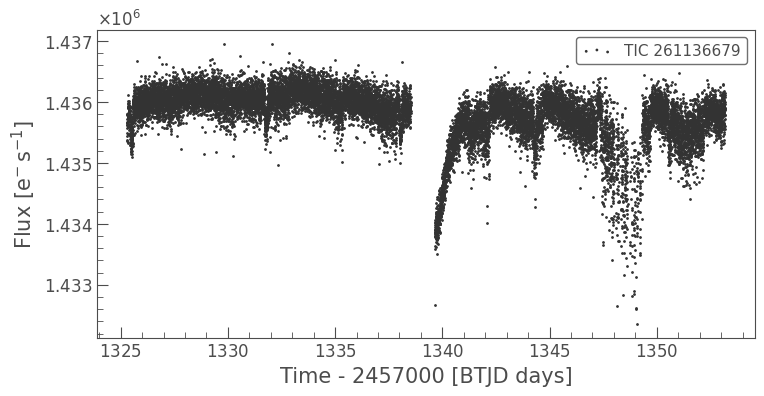

In [37]:
lc=tpf.to_lightcurve()
lc.scatter();

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

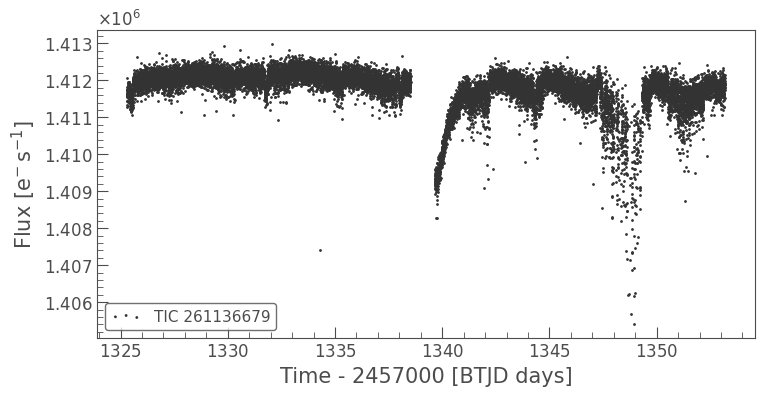

In [38]:
aperture_mask=tpf.create_threshold_mask(threshold=10)
lc=tpf.to_lightcurve(aperture_mask=aperture_mask)
lc.scatter()

.

**Explanation:**



> Create our own aperture mask. Instead of using the aperture mask automatically selected by the TESS pipeline, we're creating our own mask.

*What is a threshold mask?*

It examines the pixels in the Target Pixel File and selects pixels whose brightness is above a certain threshold.

Here:

threshold=10

sets the threshold used to decide which pixels should be included.






TESS Target Pixel File

        ↓
Our threshold-based aperture mask

        ↓
Select those pixels

        ↓
Add their flux

        ↓
Create light curve


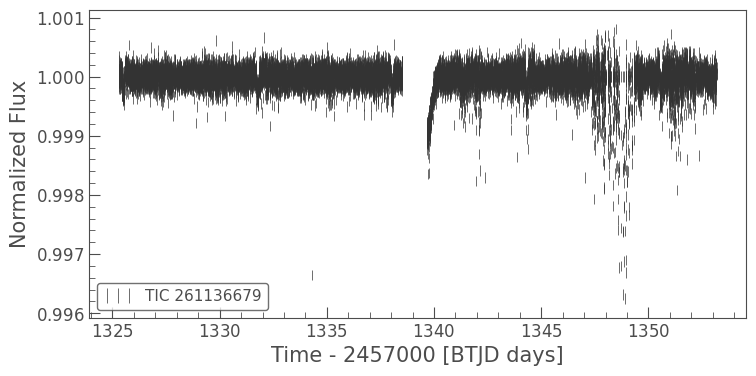

In [39]:
# Let's make the graph easier to analyze

flat_lc=lc.flatten(window_length=1001)
flat_lc.errorbar();

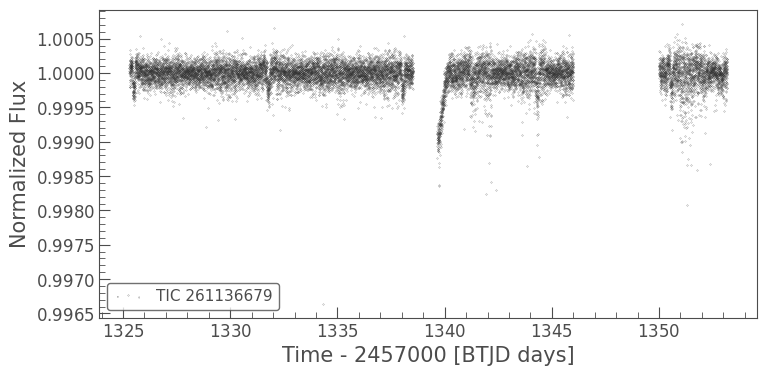

In [69]:
mask=(flat_lc.time.value <1346) | (flat_lc.time.value >1350)
masked_lc=flat_lc[mask]
masked_lc.scatter(s=0.1);

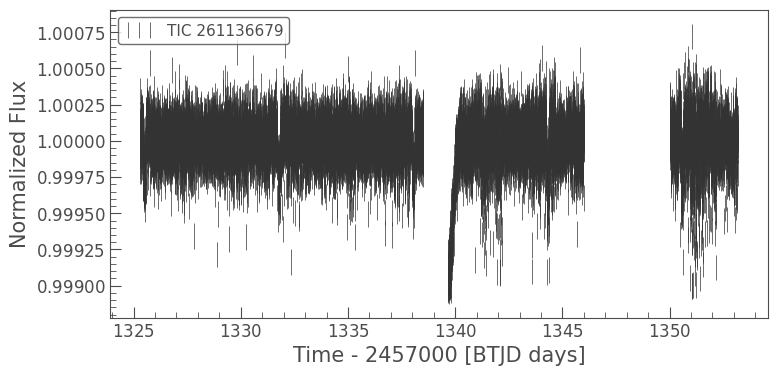

In [70]:
# Removing the outliers

clipped_lc=masked_lc.remove_outliers(sigma=6)
clipped_lc.errorbar();


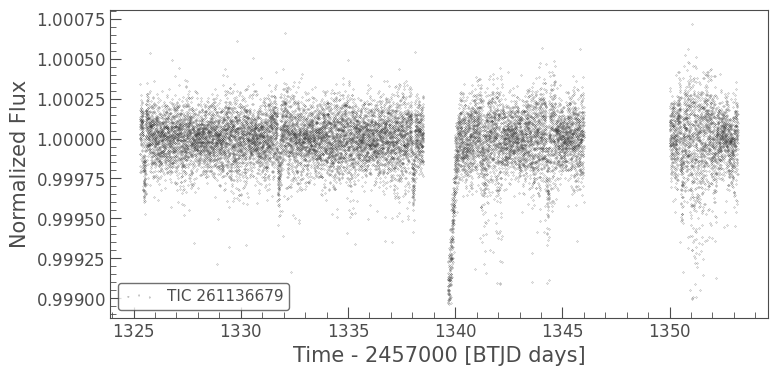

In [71]:
clipped_lc.scatter(s=0.1);

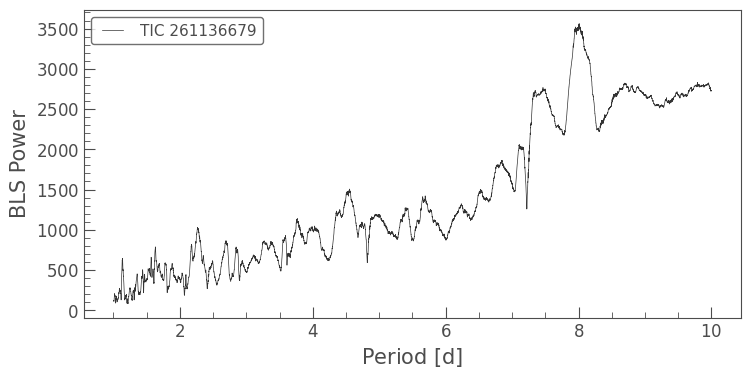

In [77]:
import numpy as np
periodogram=clipped_lc.to_periodogram(method='bls',period=np.arange(1, 10, 0.001))
periodogram.plot();

In [78]:
best_fit_period=periodogram.period_at_max_power
print('Best Fit Period: {: .3f}'.format(best_fit_period))

Best Fit Period:  8.010 d


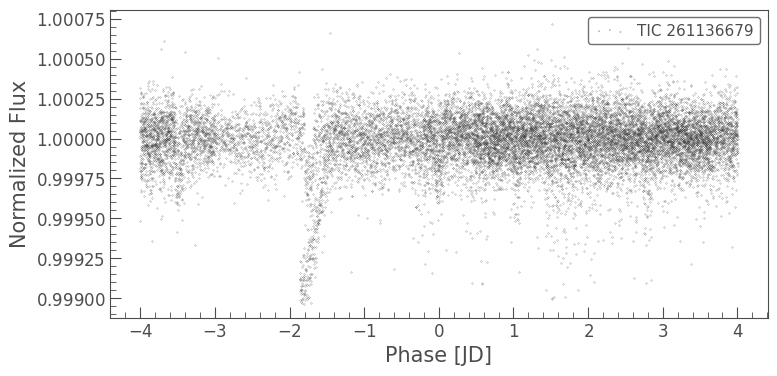

In [80]:
folded_lc = clipped_lc.fold(
    period=8.010,
    epoch_time=1325.504
)

folded_lc.scatter(s=0.1);

In [84]:
gap_data = masked_lc.time.value[
    (masked_lc.time.value >= 1346) &
    (masked_lc.time.value <= 1350)
]

print(gap_data)

[]


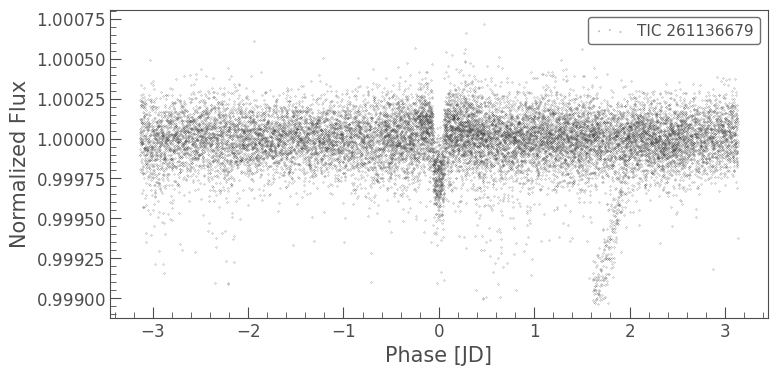

In [85]:
folded_test = clipped_lc.fold(
    period=6.27,
    epoch_time=1325.504
)

folded_test.scatter(s=0.1);

.

***Note: When applying BLS to this dataset, the strongest periodogram peak may not correspond to the known planetary period. BLS can be affected by instrumental systematics, stellar variability, data gaps, and other transit-like features. Therefore, candidate periods should be validated by folding the light curve and checking whether the signal repeats consistently.***

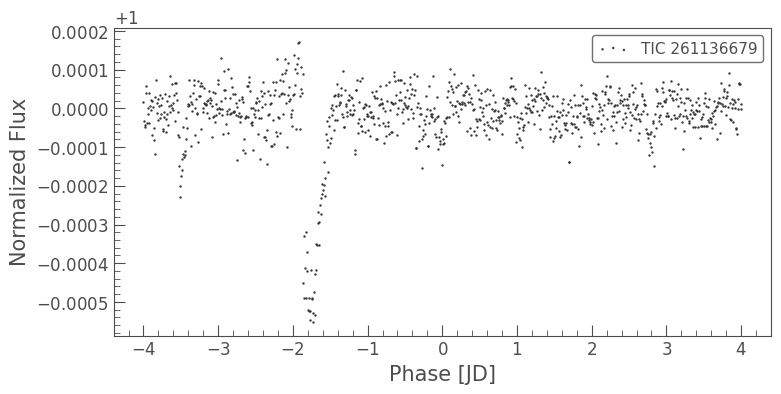

In [102]:
binned_lc=folded_lc.bin(bins=1000)
binned_lc.scatter(s=2);